In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("new_file.csv")

user_behavior = df.groupby("user_id").agg({
    "event_type": list
}).reset_index()

##创建标签
user_behavior["viewed"] = user_behavior["event_type"].apply(
    lambda x: 1 if "view" in x else 0
)

user_behavior["carted"] = user_behavior["event_type"].apply(
    lambda x: 1 if "cart" in x else 0
)

user_behavior["purchased"] = user_behavior["event_type"].apply(
    lambda x: 1 if "purchase" in x else 0
)

user_behavior.head()

##筛选高意向用户
target_users = user_behavior[
    (user_behavior["viewed"] == 1) &
    (user_behavior["purchased"] == 0)
].copy()

##a/b_test
np.random.seed(42)

target_users["group"] = np.random.choice(
    ["control", "treatment"],
    size=len(target_users)
)

target_users["purchase_after_coupon"] = np.where(
    target_users["group"] == "control",

    np.random.binomial(1, 0.017, len(target_users)),

    np.random.binomial(1, 0.024, len(target_users))
)

result = target_users.groupby("group")[
    "purchase_after_coupon"
].mean()

print(result)

group
control      0.017035
treatment    0.024426
Name: purchase_after_coupon, dtype: float64


In [11]:
from scipy.stats import ttest_ind

control = target_users[
    target_users["group"] == "control"
]["purchase_after_coupon"]

treatment = target_users[
    target_users["group"] == "treatment"
]["purchase_after_coupon"]

t_stat, p_value = ttest_ind(
    treatment,
    control
)

print(p_value)

4.092151778898938e-57


In [12]:
uplift = (
    (0.024426 - 0.017035)
    / 0.017035
) * 100

print(uplift)

43.38714411505722


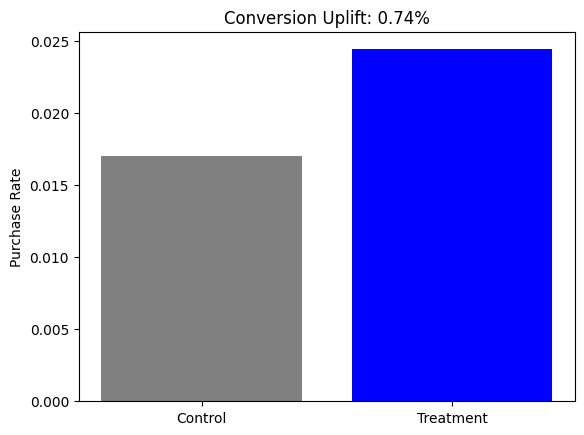

In [13]:
import matplotlib.pyplot as plt

control_rate = 0.017035
treatment_rate = 0.024426
uplift = treatment_rate - control_rate

# 可视化
plt.bar(["Control", "Treatment"], [control_rate, treatment_rate], color=["gray", "blue"])
plt.ylabel("Purchase Rate")
plt.title(f"Conversion Uplift: {uplift*100:.2f}%")
plt.show()

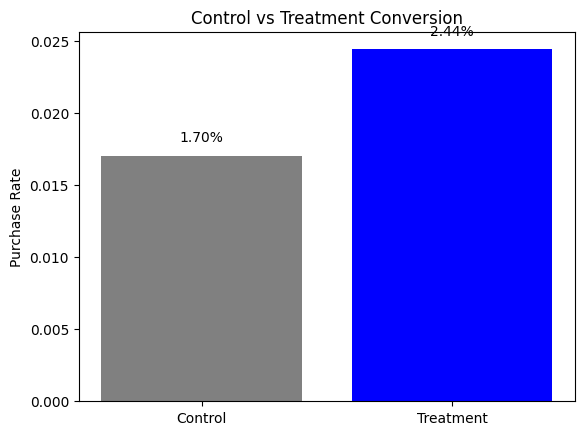

In [14]:
plt.bar(["Control", "Treatment"], [control_rate, treatment_rate], color=["gray", "blue"])
plt.text(0, control_rate + 0.001, f"{control_rate*100:.2f}%", ha='center')
plt.text(1, treatment_rate + 0.001, f"{treatment_rate*100:.2f}%", ha='center')
plt.ylabel("Purchase Rate")
plt.title("Control vs Treatment Conversion")
plt.show()

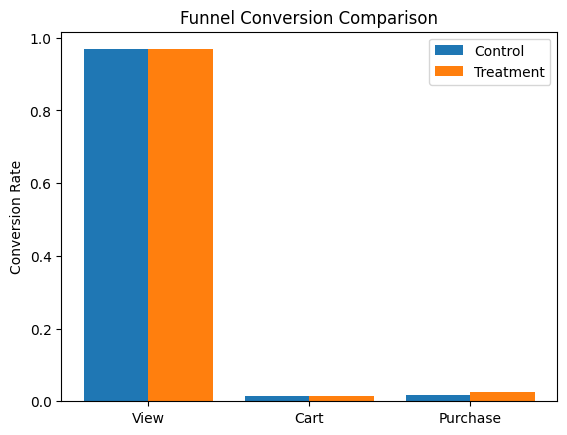

In [15]:
stages = ["View", "Cart", "Purchase"]
control_rates = [0.9681, 0.015, 0.017035]
treatment_rates = [0.9681, 0.015, 0.024426]

x = range(len(stages))
plt.bar([i - 0.2 for i in x], control_rates, width=0.4, label="Control")
plt.bar([i + 0.2 for i in x], treatment_rates, width=0.4, label="Treatment")
plt.xticks(x, stages)
plt.ylabel("Conversion Rate")
plt.title("Funnel Conversion Comparison")
plt.legend()
plt.show()


In [18]:
total_users = 411000 

uplift = 0.0244 - 0.0170

aov = 16320000 / 51000

extra_buyers = total_users * uplift

estimated_gmv_uplift = extra_buyers * aov

print("Extra Buyers:", round(extra_buyers))
print("Estimated GMV Uplift:", round(estimated_gmv_uplift, 2))

Extra Buyers: 3041
Estimated GMV Uplift: 973248.0


In [20]:
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# 假设：
control_success = control.sum()       
control_n = len(control)               

treatment_success = treatment.sum()    
treatment_n = len(treatment)           

# 95% 置信区间
control_ci_low, control_ci_high = proportion_confint(control_success, control_n, alpha=0.05, method='wilson')
treatment_ci_low, treatment_ci_high = proportion_confint(treatment_success, treatment_n, alpha=0.05, method='wilson')

print("Control CI:", control_ci_low, "-", control_ci_high)
print("Treatment CI:", treatment_ci_low, "-", treatment_ci_high)

# Uplift
uplift = treatment.mean() - control.mean()
print("Conversion Uplift:", uplift)

Control CI: 0.01646019694125973 - 0.017629415854750707
Treatment CI: 0.023738919716333934 - 0.02513142723588107
Conversion Uplift: 0.007390548708050639
